In [1]:
### LOADING DATASET
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_from_disk
from transformers import PreTrainedTokenizerFast #using transformers package for tokenization

In [2]:
def load_tokenizers(base_dir: str = "/kaggle/input/datasets/saraahmad4/dataset"):
    """
    Load the French (src) and English (tgt) BPE tokenizers
    from the provided tokenizer folders.
    """
    fr_path = f"{base_dir}/tokenizer_fr"
    en_path = f"{base_dir}/tokenizer_en"
 
    src_tokenizer = PreTrainedTokenizerFast.from_pretrained(fr_path)
    tgt_tokenizer = PreTrainedTokenizerFast.from_pretrained(en_path)
 
    # Ensure special tokens are set
    for tok in [src_tokenizer, tgt_tokenizer]:
        if tok.pad_token is None:
            tok.add_special_tokens({"pad_token": "<pad>"})
        if tok.bos_token is None:
            tok.add_special_tokens({"bos_token": "<s>"})
        if tok.eos_token is None:
            tok.add_special_tokens({"eos_token": "</s>"})
 
    print(f"FR tokenizer vocab size : {src_tokenizer.vocab_size}")
    print(f"EN tokenizer vocab size : {tgt_tokenizer.vocab_size}")
    print(f"PAD id  — FR: {src_tokenizer.pad_token_id} | EN: {tgt_tokenizer.pad_token_id}")
    print(f"BOS id  — EN: {tgt_tokenizer.bos_token_id}")
    print(f"EOS id  — EN: {tgt_tokenizer.eos_token_id}")
 
    return src_tokenizer, tgt_tokenizer

In [3]:
def inspect_dataset(base_dir: str = "/kaggle/input/datasets/saraahmad4/dataset"):
    """
    Call this once to see what columns the Arrow dataset has.
    This tells us the exact field names for French and English.
    """
    dataset = load_from_disk(f"{base_dir}/parallel_en_fr_corpus")
    print(dataset)
    print("\nColumn names:", dataset["train"].column_names)
    print("\nFirst example:", dataset["train"][0])
    return dataset

In [4]:
class TranslationDataset(Dataset):
    """
    Wraps one split (train / validation / test) of the Arrow dataset.
 
    The Arrow dataset likely stores each example as:
        {"translation": {"en": "...", "fr": "..."}}
    OR as flat columns:
        {"en": "...", "fr": "..."}
 
    We handle both cases automatically.
    """
 
    def __init__(
        self,
        hf_split,                          # one HuggingFace dataset split
        src_tokenizer: PreTrainedTokenizerFast,
        tgt_tokenizer: PreTrainedTokenizerFast,
        src_lang: str = "text_fr",         # French = source
        tgt_lang: str = "text_en",         # English = target
        max_len: int = 32,
    ):
        self.max_len = max_len
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
 
        # ── Detect column layout ──────────────────────────────────────────
        cols = hf_split.column_names
        print(f"Dataset columns: {cols}")
 
        if "translation" in cols:
            # Nested format: {"translation": {"en": ..., "fr": ...}}
            src_sentences = [ex["translation"][src_lang] for ex in hf_split]
            tgt_sentences = [ex["translation"][tgt_lang] for ex in hf_split]
        elif src_lang in cols and tgt_lang in cols:
            # Flat format: {"en": ..., "fr": ...}
            src_sentences = list(hf_split[src_lang])
            tgt_sentences = list(hf_split[tgt_lang])
        else:
            raise ValueError(
                f"Cannot find '{src_lang}'/'{tgt_lang}' in columns: {cols}\n"
                f"Call inspect_dataset() to see the actual column names."
            )
 
        print(f"  Loaded {len(src_sentences)} sentence pairs.")
 
        # ── Tokenize everything up front ──────────────────────────────────
        self.src_ids = self._encode(src_tokenizer, src_sentences)
        self.tgt_ids = self._encode(tgt_tokenizer, tgt_sentences)
 
    def _encode(self, tokenizer, sentences):
        encoded = tokenizer(
            sentences,
            truncation=True,
            max_length=self.max_len,
            add_special_tokens=False,   # we add BOS/EOS manually below
        )
        return [torch.tensor(ids, dtype=torch.long) for ids in encoded["input_ids"]]
 
    def __len__(self):
        return len(self.src_ids)
 
    def __getitem__(self, idx):
        src = self.src_ids[idx]
 
        raw_tgt = self.tgt_ids[idx]
        bos = self.tgt_tokenizer.bos_token_id
        eos = self.tgt_tokenizer.eos_token_id
 
        # decoder_input : [BOS, t1, t2, ...]   — fed into the decoder
        # label         : [t1, t2, ..., EOS]   — what the model should predict
        decoder_input = torch.cat([torch.tensor([bos]), raw_tgt])[: self.max_len]
        label         = torch.cat([raw_tgt, torch.tensor([eos])])[: self.max_len]
 
  
        return src, decoder_input, label

In [5]:
def make_collate_fn(src_pad_id: int, tgt_pad_id: int):
    """
    Pads a batch of variable-length sequences.
 
    Returns:
        src_batch        (B, S) — padded French source
        dec_input_batch  (B, T) — padded decoder inputs  [BOS + tokens]
        label_batch      (B, T) — padded labels          [tokens + EOS]
        src_lengths      (B,)   — true source lengths (for LSTM packing)
        tgt_lengths      (B,)   — true target lengths
    """
    def collate_fn(batch):
        src_seqs, dec_inputs, labels = zip(*batch)
 
        src_lengths = torch.tensor([len(s) for s in src_seqs])
        tgt_lengths = torch.tensor([len(l) for l in labels])
 
        src_batch       = pad_sequence(src_seqs,   batch_first=True, padding_value=src_pad_id)
        dec_input_batch = pad_sequence(dec_inputs, batch_first=True, padding_value=tgt_pad_id)
        label_batch     = pad_sequence(labels,     batch_first=True, padding_value=tgt_pad_id)
 
        return src_batch, dec_input_batch, label_batch, src_lengths, tgt_lengths
 
    return collate_fn

In [6]:

def get_dataloaders(
    base_dir: str = "/kaggle/input/datasets/saraahmad4/dataset",
    batch_size: int = 32,
    max_len: int = 32,
    num_workers: int = 2,
):
    """
    Full pipeline:
        load tokenizers → load Arrow dataset → build DataLoaders
 
    Returns:
        train_loader, val_loader, test_loader,
        src_tokenizer (FR), tgt_tokenizer (EN)
    """
    src_tok, tgt_tok = load_tokenizers(base_dir)
 
    raw = load_from_disk(f"{base_dir}/parallel_en_fr_corpus")
    print(f"\nDataset splits: {list(raw.keys())}")
 
    train_ds = TranslationDataset(raw["train"],      src_tok, tgt_tok, max_len=max_len)
    val_ds   = TranslationDataset(raw["validation"], src_tok, tgt_tok, max_len=max_len)
    test_ds  = TranslationDataset(raw["test"],       src_tok, tgt_tok, max_len=max_len)
 
    collate_fn = make_collate_fn(
        src_pad_id=src_tok.pad_token_id,
        tgt_pad_id=tgt_tok.pad_token_id,
    )
 
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)
 
    return train_loader, val_loader, test_loader, src_tok, tgt_tok

In [7]:
if __name__ == "__main__":
    import sys
 
    base_dir = r"/kaggle/input/datasets/saraahmad4/dataset"
 
    print("=" * 50)
    print("Step 1: Inspecting raw dataset...")
    print("=" * 50)
    inspect_dataset(base_dir)
 
    print("\n" + "=" * 50)
    print("Step 2: Building DataLoaders...")
    print("=" * 50)
    train_loader, val_loader, test_loader, src_tok, tgt_tok = get_dataloaders(
        base_dir=base_dir, batch_size=4, max_len=32
    )
 
    print("\n" + "=" * 50)
    print("Step 3: Checking one batch...")
    print("=" * 50)
    src, dec_input, labels, src_len, tgt_len = next(iter(train_loader))
    print(f"src shape        : {src.shape}")
    print(f"dec_input shape  : {dec_input.shape}")
    print(f"labels shape     : {labels.shape}")
    print(f"src_lengths      : {src_len}")
 
    print("\nDecoding first example:")
    print(f"  FR (src)  : {src_tok.decode(src[0].tolist(), skip_special_tokens=True)}")
    print(f"  EN (label): {tgt_tok.decode(labels[0].tolist(), skip_special_tokens=True)}")
    print("\nAll good!")

Step 1: Inspecting raw dataset...
DatasetDict({
    train: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 8701
    })
    validation: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 485
    })
    test: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 486
    })
})

Column names: ['text_en', 'text_fr']

First example: {'text_en': 'i m tough .', 'text_fr': 'je suis dure .'}

Step 2: Building DataLoaders...
FR tokenizer vocab size : 3200
EN tokenizer vocab size : 3200
PAD id  — FR: 3 | EN: 3
BOS id  — EN: 1
EOS id  — EN: 2

Dataset splits: ['train', 'validation', 'test']
Dataset columns: ['text_en', 'text_fr']
  Loaded 8701 sentence pairs.
Dataset columns: ['text_en', 'text_fr']
  Loaded 485 sentence pairs.
Dataset columns: ['text_en', 'text_fr']
  Loaded 486 sentence pairs.

Step 3: Checking one batch...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


src shape        : torch.Size([4, 8])
dec_input shape  : torch.Size([4, 10])
labels shape     : torch.Size([4, 10])
src_lengths      : tensor([7, 6, 8, 8])

Decoding first example:
  FR (src)  : ▁il ▁craint ▁d ▁etre ▁en ▁retard ▁.
  EN (label): ▁he ▁s ▁afraid ▁that ▁he ▁might ▁be ▁late ▁.

All good!


In [8]:
### BLEU SCORES FUNCTIONS
import os
import torch
from torchmetrics.text import BLEUScore

In [9]:
def save_checkpoint(
    model,
    optimizer,
    epoch: int,
    val_bleu: float,
    checkpoint_dir: str,
    model_name: str,
):
    """
    Save model + optimizer state to disk.
 
    Saves two files:
      - {model_name}_epoch{epoch}.pt  — full snapshot for resuming
      - {model_name}_best.pt          — overwritten whenever val_bleu improves
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
 
    state = {
        "epoch": epoch,
        "val_bleu": val_bleu,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }
 
    epoch_path = os.path.join(checkpoint_dir, f"{model_name}_epoch{epoch}.pt")
    torch.save(state, epoch_path)
    print(f"  [Checkpoint] Saved: {epoch_path}")
 
    # Track best model separately
    best_path = os.path.join(checkpoint_dir, f"{model_name}_best.pt")
    if not os.path.exists(best_path):
        torch.save(state, best_path)
        print(f"  [Checkpoint] New best: {val_bleu:.2f} BLEU")
    else:
        prev = torch.load(best_path, map_location="cpu", weights_only=True)
        if val_bleu > prev.get("val_bleu", 0):
            torch.save(state, best_path)
            print(f"  [Checkpoint] New best: {val_bleu:.2f} BLEU "
                  f"(was {prev['val_bleu']:.2f})")

In [10]:
def load_checkpoint(model, optimizer, checkpoint_path: str, device):
    """
    Load a checkpoint. Restores model weights and optimizer state.
 
    Returns:
        start_epoch (int): epoch to resume from
        best_bleu   (float): best BLEU seen so far
    """
    if not os.path.exists(checkpoint_path):
        print(f"  [Checkpoint] No checkpoint at {checkpoint_path}, starting fresh.")
        return 0, 0.0
 
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state["model_state_dict"])
    optimizer.load_state_dict(state["optimizer_state_dict"])
 
    epoch    = state.get("epoch", 0)
    val_bleu = state.get("val_bleu", 0.0)
    print(f"  [Checkpoint] Loaded epoch {epoch}, val BLEU {val_bleu:.2f}")
    return epoch + 1, val_bleu

In [11]:
def compute_bleu(
    hypotheses: list[str],
    references: list[str],
) -> float:
    """
    Compute corpus-level BLEU score using sacrebleu.
 
    Args:
        hypotheses: list of decoded prediction strings (one per sentence)
        references: list of ground-truth strings (one per sentence)
 
    Returns:
        BLEU score as a float (0–100)
 
    Example:
        bleu = compute_bleu(
            hypotheses=["the cat sat on the mat"],
            references=["the cat is on the mat"],
        )
    """
    result = sacrebleu.corpus_bleu(hypotheses, [references])
    return result.score

In [12]:
# One shared instance — n_gram=4 is standard BLEU-4
_bleu_metric = BLEUScore(n_gram=4)
 
def compute_bleu(
    hypotheses: list,
    references: list,
) -> float:
    """
    Compute corpus-level BLEU-4 score using torchmetrics.
 
    Args:
        hypotheses: list of predicted strings, one per sentence
                    e.g. ["the cat sat on the mat", ...]
        references: list of ground-truth strings, one per sentence
                    e.g. ["the cat is on the mat", ...]
 
    Returns:
        BLEU score as a float (0–100)
 
    Note:
        torchmetrics BLEUScore expects references as a list of lists
        (to support multiple references per sentence), so we wrap each
        reference string in a list automatically.
    """
    # torchmetrics expects: refs = [[ref1], [ref2], ...]
    wrapped_refs = [[r] for r in references]
    score = _bleu_metric(hypotheses, wrapped_refs)
    return score.item() * 100   # return as 0–100 like sacrebleu
 

In [13]:
def decode_predictions(
    token_ids_batch,       # (B, T) tensor or list of predicted token ids
    tokenizer,
    eos_token_id: int,
) -> list:
    """
    Convert a batch of token-id tensors into human-readable strings.
    Stops at EOS and strips special tokens (including the ▁ artifacts).
 
    Used by both Transformer (Member 2) and LSTM (Member 3).
    """
    sentences = []
    for ids in token_ids_batch:
        ids = ids.tolist() if hasattr(ids, "tolist") else list(ids)
        # Truncate at EOS if present
        if eos_token_id in ids:
            ids = ids[: ids.index(eos_token_id)]
        text = tokenizer.decode(ids, skip_special_tokens=True)
        sentences.append(text)
    return sentences

In [14]:
if __name__ == "__main__":
    print("Testing compute_bleu...")
    hyps = ["the cat is on the mat", "hello world"]
    refs = ["the cat is on the mat", "hello world"]
    print(f"  Perfect match BLEU: {compute_bleu(hyps, refs):.2f}")   # should be 100.0
 
    hyps2 = ["the cat sat on the mat", "hi world"]
    print(f"  Imperfect BLEU:     {compute_bleu(hyps2, refs):.2f}")  # should be ~50-60
 
    print("utils.py OK!")

Testing compute_bleu...
  Perfect match BLEU: 100.00
  Imperfect BLEU:     0.00
utils.py OK!


In [15]:
"""
### TRAINER
Shared training loop used by both the Transformer (Member 2)
and the LSTM (Member 3).
 
Each model just needs to implement a forward() that accepts:
    src, decoder_input, src_lengths → logits (B, T, vocab_size)
 
Everything else (loss, optimizer step, val loop, BLEU) lives here.
"""
import torch
import torch.nn as nn

In [16]:
class Trainer:
    """
    Generic trainer for sequence-to-sequence NMT models.
 
    Usage:
        trainer = Trainer(model, optimizer, train_loader, val_loader,
                          tgt_tokenizer, device, checkpoint_dir, model_name)
        trainer.train(num_epochs=10)
    """
 
    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        train_loader,
        val_loader,
        tgt_tokenizer,
        device: torch.device,
        checkpoint_dir: str = "checkpoints",
        model_name: str = "model",
        pad_token_id: int = 0,
    ):
        self.model          = model.to(device)
        self.optimizer      = optimizer
        self.train_loader   = train_loader
        self.val_loader     = val_loader
        self.tgt_tokenizer  = tgt_tokenizer
        self.device         = device
        self.checkpoint_dir = checkpoint_dir
        self.model_name     = model_name
        self.pad_token_id   = pad_token_id
 
        # Cross-entropy loss; ignore PAD positions
        self.criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)
 
    # ──────────────────────────────────────────
    # Training
    # ──────────────────────────────────────────
 
    def train(self, num_epochs: int, start_epoch: int = 0):
        for epoch in range(start_epoch, num_epochs):
            train_loss = self._train_epoch(epoch)
            val_loss, val_bleu = self._val_epoch(epoch)
 
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train loss: {train_loss:.4f} | "
                f"Val loss: {val_loss:.4f} | "
                f"Val BLEU: {val_bleu:.2f}"
            )
 
            save_checkpoint(
                self.model, self.optimizer,
                epoch, val_bleu,
                self.checkpoint_dir, self.model_name,
            )
 
    def _train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0
 
        for batch_idx, (src, dec_input, labels, src_lengths, _) in enumerate(self.train_loader):
            src        = src.to(self.device)
            dec_input  = dec_input.to(self.device)
            labels     = labels.to(self.device)
            src_lengths = src_lengths.to(self.device)
 
            self.optimizer.zero_grad()
 
            # --- Forward pass ---
            # model.forward() must return logits of shape (B, T, vocab_size)
            logits = self.model(src, dec_input, src_lengths)
 
            # Flatten for cross-entropy: (B*T, vocab) vs (B*T,)
            loss = self.criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
            )
 
            loss.backward()
 
            # Gradient clipping prevents exploding gradients (common in RNNs)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
 
            self.optimizer.step()
            total_loss += loss.item()
 
            if (batch_idx + 1) % 100 == 0:
                print(f"  Step {batch_idx+1} | Loss: {loss.item():.4f}")
 
        return total_loss / len(self.train_loader)
 
    # ──────────────────────────────────────────
    # Validation
    # ──────────────────────────────────────────
 
    def _val_epoch(self, epoch: int):
        self.model.eval()
        total_loss  = 0.0
        hypotheses  = []
        references  = []
 
        eos_id = self.tgt_tokenizer.eos_token_id
        bos_id = self.tgt_tokenizer.bos_token_id
 
        with torch.no_grad():
            for src, dec_input, labels, src_lengths, _ in self.val_loader:
                src        = src.to(self.device)
                dec_input  = dec_input.to(self.device)
                labels     = labels.to(self.device)
                src_lengths = src_lengths.to(self.device)
 
                logits = self.model(src, dec_input, src_lengths)
 
                loss = self.criterion(
                    logits.reshape(-1, logits.size(-1)),
                    labels.reshape(-1),
                )
                total_loss += loss.item()
 
                # Greedy decoding for BLEU (beam search added by Member 4)
                pred_ids = logits.argmax(dim=-1)   # (B, T)
                hyps = decode_predictions(pred_ids, self.tgt_tokenizer, eos_id)
                refs = decode_predictions(labels,   self.tgt_tokenizer, eos_id)
 
                hypotheses.extend(hyps)
                references.extend(refs)
 
        avg_loss = total_loss / len(self.val_loader)
        bleu     = compute_bleu(hypotheses, references)
        return avg_loss, bleu

In [17]:
import torch
import torch.nn as nn
import math

def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Computes vectorized scaled dot-product attention.
    q, k, v shapes: (Batch, Heads, SeqLen, d_k)
    """
    d_k = q.size(-1)
    # 1. Matrix multiply q and k^T, then scale
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    
    # 2. Apply masks (large negative value for pad/future tokens)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
        
    # 3. Softmax
    attn_weights = torch.softmax(scores, dim=-1)
    
    # CONSTRAINT CHECK: "No dropout in... the attention weights" -> Omitted here
    
    # 4. Multiply with values
    output = torch.matmul(attn_weights, v)
    return output, attn_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Apply linear projections and split into heads: (B, H, SeqLen, d_k)
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Compute attention
        x, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads back together and project
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(x)
        
        return output, attn_weights

In [18]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.dropout(self.w_2(self.relu(self.w_1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout) # Allowed in FF/Norm blocks

    def forward(self, x, mask):
        # Sublayer 1: Self Attention & AddNorm
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        
        # Sublayer 2: FeedForward & AddNorm
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        # Sublayer 1: Masked Self Attention (causal + pad mask)
        attn1, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn1))

        # Sublayer 2: Cross Attention (attending to encoder outputs)
        attn2, attn_weights = self.cross_attn(x, memory, memory, src_mask)
        x = self.norm2(x + self.dropout(attn2))

        # Sublayer 3: FeedForward
        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x, attn_weights

In [19]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size_enc, vocab_size_dec, pad_token_id,
                 d_model=32, nhead=4, num_encoder_layers=3, num_decoder_layers=3,
                 dim_feedforward=128, max_seq_length=32, dropout=0.1):
        super().__init__()
        self.pad_token_id = pad_token_id

        # 1. Embeddings (CONSTRAINT: Learned positional, NO dropout)
        self.src_tok_emb = nn.Embedding(vocab_size_enc, d_model)
        self.src_pos_emb = nn.Embedding(max_seq_length, d_model)
        
        self.tgt_tok_emb = nn.Embedding(vocab_size_dec, d_model)
        self.tgt_pos_emb = nn.Embedding(max_seq_length, d_model)

        # 2. Layer Stacks
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, nhead, dim_feedforward, dropout) for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, nhead, dim_feedforward, dropout) for _ in range(num_decoder_layers)
        ])

        # 3. Output Projection
        self.projection = nn.Linear(d_model, vocab_size_dec, bias=False)

        # CONSTRAINT CHECK: Weight Tying
        self.projection.weight = self.tgt_tok_emb.weight

    def make_src_mask(self, src):
        # (B, 1, 1, S)
        src_mask = (src != self.pad_token_id).unsqueeze(1).unsqueeze(2)
        return src_mask

    def make_tgt_mask(self, tgt):
        # 1. Pad Mask: (B, 1, 1, T)
        tgt_pad_mask = (tgt != self.pad_token_id).unsqueeze(1).unsqueeze(2)
        
        # 2. Causal Mask: (T, T)
        seq_len = tgt.size(1)
        tgt_sub_mask = torch.tril(torch.ones((seq_len, seq_len), device=tgt.device)).bool()
        
        # Combine (Broadcasts to (B, 1, T, T))
        tgt_mask = tgt_pad_mask & tgt_sub_mask
        return tgt_mask

    def forward(self, src, dec_input, src_lengths):
        """
        src: (B, S) - padded French token ids
        dec_input: (B, T) - padded English decoder input
        src_lengths: (B,) - Ignored for Transformer, required by Trainer signature
        """
        batch_size, src_len = src.size()
        _, tgt_len = dec_input.size()

        # Generate Masks
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(dec_input)

        # Create Position Tensors
        src_positions = torch.arange(0, src_len, device=src.device).unsqueeze(0).expand(batch_size, src_len)
        tgt_positions = torch.arange(0, tgt_len, device=dec_input.device).unsqueeze(0).expand(batch_size, tgt_len)

        # Encoder Forward (Sum of token and positional)
        enc_out = self.src_tok_emb(src) + self.src_pos_emb(src_positions)
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        # Decoder Forward
        dec_out = self.tgt_tok_emb(dec_input) + self.tgt_pos_emb(tgt_positions)
        for layer in self.decoder_layers:
            dec_out, _ = layer(dec_out, enc_out, src_mask, tgt_mask)

        # Output Projection
        logits = self.projection(dec_out) # Shape: (B, T, vocab_size)
        return logits

In [20]:

# 1. Load Data
train_loader, val_loader, test_loader, src_tok, tgt_tok = get_dataloaders()

# 2. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 3. Model Parameters (Strictly from the assignment table)
d_model = 32
nhead = 4
num_encoder_layers = 3
num_decoder_layers = 3
dim_feedforward = 128  # 32 x 4 intermediate size
max_seq_length = 32
dropout = 0.1
learning_rate = 1e-3

# 4. Instantiate Your Model
model = TransformerModel(
    vocab_size_enc=src_tok.vocab_size,
    vocab_size_dec=tgt_tok.vocab_size,
    pad_token_id=tgt_tok.pad_token_id,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    max_seq_length=max_seq_length,
    dropout=dropout
).to(device)

# 5. Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 6. Instantiate Member 1's Trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    tgt_tokenizer=tgt_tok,
    device=device,
    checkpoint_dir="checkpoints",
    model_name="transformer",
    pad_token_id=tgt_tok.pad_token_id
)

# 7. Start Training!
trainer.train(num_epochs=10)

FR tokenizer vocab size : 3200
EN tokenizer vocab size : 3200
PAD id  — FR: 3 | EN: 3
BOS id  — EN: 1
EOS id  — EN: 2

Dataset splits: ['train', 'validation', 'test']
Dataset columns: ['text_en', 'text_fr']
  Loaded 8701 sentence pairs.
Dataset columns: ['text_en', 'text_fr']
  Loaded 485 sentence pairs.
Dataset columns: ['text_en', 'text_fr']
  Loaded 486 sentence pairs.
Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Step 100 | Loss: 5.8166
  Step 200 | Loss: 4.6400
Epoch 1/10 | Train loss: 6.1598 | Val loss: 3.6121 | Val BLEU: 0.00
  [Checkpoint] Saved: checkpoints/transformer_epoch0.pt
  [Checkpoint] New best: 0.00 BLEU
  Step 100 | Loss: 3.3168
  Step 200 | Loss: 3.4870
Epoch 2/10 | Train loss: 3.4025 | Val loss: 3.0219 | Val BLEU: 7.93
  [Checkpoint] Saved: checkpoints/transformer_epoch1.pt
  [Checkpoint] New best: 7.93 BLEU (was 0.00)
  Step 100 | Loss: 2.9966
  Step 200 | Loss: 3.0558
Epoch 3/10 | Train loss: 2.9880 | Val loss: 2.8024 | Val BLEU: 10.49
  [Checkpoint] Saved: checkpoints/transformer_epoch2.pt
  [Checkpoint] New best: 10.49 BLEU (was 7.93)
  Step 100 | Loss: 2.8037
  Step 200 | Loss: 2.8079
Epoch 4/10 | Train loss: 2.7878 | Val loss: 2.6800 | Val BLEU: 12.53
  [Checkpoint] Saved: checkpoints/transformer_epoch3.pt
  [Checkpoint] New best: 12.53 BLEU (was 10.49)
  Step 100 | Loss: 2.7976
  Step 200 | Loss: 2.8495
Epoch 5/10 | Train loss: 2.6469 | Val loss: 2.5780 | Val BLEU: 14.

## Part 2: LSTM Seq2Seq with Additive Attention

### General Flow

The LSTM model translates French → English in 5 stages:

---

### Stage 1: Embedding
Each French token is converted to a vector (embed_size=256).

---

### Stage 2: Bi-LSTM Encoder
The French sentence is read **twice**  forward and backward.
At each position i, the two hidden states are concatenated:

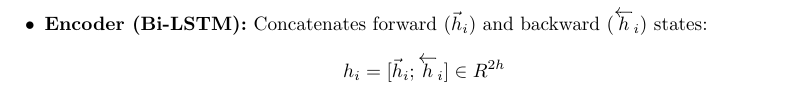

This gives every French word context from both sides.

---

### Stage 3: Decoder Initialization
The decoder needs a starting hidden state s₀.
We project the encoder's final states down to decoder size:

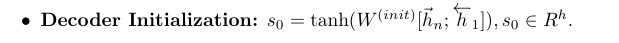
    
### Decoder Initialization Why [h_n_fwd ; h_1_bwd]?

The Bi-LSTM reads the sentence in two directions:

    Forward  →:  Le → chat → est → rapide
                                      ↑
                                 h_n_fwd  (has seen ALL tokens from position 1 to n)

    Backward ←:  Le ← chat ← est ← rapide
                  ↑
             h_1_bwd  (has seen ALL tokens from position n back to 1)

Each hidden state hᵢ summarizes everything the LSTM has seen UP TO position i.
So the final state of each direction has seen the ENTIRE sentence.

- h_n_fwd  = summary of the whole sentence going left → right
- h_1_bwd  = summary of the whole sentence going right → left

Together they capture the full sentence from both perspectives.
We concatenate and project to decoder size:
    s₀ = tanh(W^(init) · [h_n_fwd ; h_1_bwd])

This becomes the decoder's starting hidden state
its initial "understanding" of the French sentence.

### Stage 4: Additive Attention (at EVERY decoder step t)
The decoder asks: "which French words matter right now?"

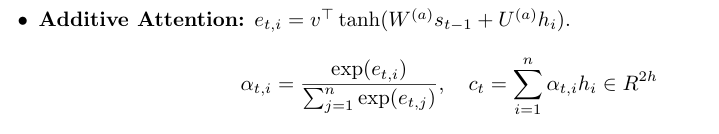
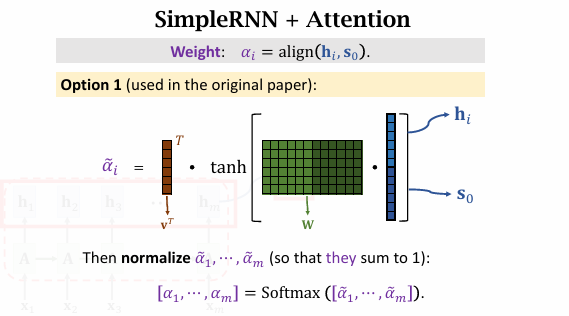

    eₜᵢ  = v · tanh(W·sₜ₋₁ + U·hᵢ)    ← score for each French word
    αₜᵢ  = softmax(eₜ)                  ← weights that sum to 1
    cₜ   = Σ αₜᵢ · hᵢ                  ← context vector
   > (context vector: at timestep t in decoder how much does each token in the encoder matter to me to predict that next token)

---

### Stage 5: Decoder LSTM Step
Feed previous English word (input) + context into the LSTM + the previous hidden state:

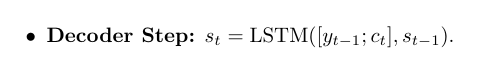

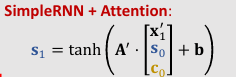
---

### Stage 6: Output
Predict the next English word:

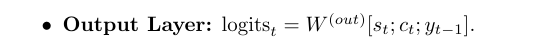

    next_word = argmax(logits)

Repeat stages 4→6 until <EOS> is predicted.

## Part 2: Seq2Seq with Bi-LSTM + Additive Attention

We are implementing a Bi-LSTM based sequence-to-sequence model for machine translation from French to English.

### The Big Picture
The model has two parts: an **encoder** that understands the French sentence, and a **decoder** that generates the English translation word by word.

---

### Encoder — Bi-LSTM

The encoder's job is to **understand** the French sentence and produce rich contextual representations of each word.

We use a **Bidirectional LSTM** it reads the sentence twice:
- **Forward →** from word 1 to word n
- **Backward ←** from word n to word 1

At each position we concatenate both hidden states:

hᵢ = [forward_hᵢ ; backward_hᵢ]   shape: 2h

This gives each token a representation that understands **both what came before and what comes after it**. This is not cheating the encoder is not generating anything, it is purely **understanding** a sentence that is already fully given to it. So seeing the whole sequence at once is not only fine but desirable.

The result is a sequence of contextual vectors `[h₁, h₂, ..., hₙ]` — one per French token — that the decoder will later read from.

---

### Decoder Initialization

Before the decoder starts generating, it needs a starting hidden state `s₀` that summarizes the entire French sentence. We compute it from the encoder's final forward and backward hidden states:

s₀ = tanh(W · [h_fwd_last ; h_bwd_last])


This projects the encoder's summary down to the decoder's hidden size `h`.

---

### Additive Attention

At each decoder step `t`, before the LSTM runs, we compute **how much each French word matters right now** using additive (Bahdanau) attention:

eₜᵢ = v · tanh(W·s_{t-1} + U·hᵢ)      ← score for each French word
αₜᵢ = softmax(eₜᵢ)                      ← attention weights (sum to 1)
cₜ  = Σ αₜᵢ · hᵢ                        ← context vector


The context vector `cₜ` is the decoder's way of saying: *"at this translation step, here is the weighted summary of the French sentence that I care about most."*

---

### Decoder — Unidirectional LSTM

The decoder generates the English translation **one word at a time**. At each step it takes:
- `y_{t-1}` — the previous English word embedding
- `cₜ` — the context vector from attention

Concatenates them and feeds into the LSTM:
sₜ = LSTM([y_{t-1} ; cₜ], s_{t-1})

The output logits are then computed by combining the decoder hidden state, context vector, and previous word:
logitsₜ = W_out · [sₜ ; cₜ ; y_{t-1}]

The highest scoring token is the predicted next English word.

---

### Training with Teacher Forcing

During training the decoder is fed the **correct** previous word at each step regardless of what it actually predicted — this is called **teacher forcing**. For example translating "Le chat est rapide" → "The cat is fast":


At each step the prediction is compared to the correct next word and **cross-entropy loss** is computed. If the prediction is wrong, the loss penalizes it and backpropagation updates the weights so the model does better next time.

---

### Input Pipeline

The model takes pairs of French and English sentences. Each sentence is tokenized using a pretrained BPE tokenizer which splits words into subword token IDs. These IDs are then used to look up vectors in an **embedding matrix** a learned table where each row corresponds to one token and contains its dense vector representation. So the model never sees raw text only embeddings derived from token IDs.

In [21]:
import torch
import torch.nn as nn

class AdditiveAttention(nn.Module):
    """
    (Additive) Attention.
    At each decoder step, computes how much each French token matters.
    eₜᵢ = v · tanh(W·s_{t-1} + U·hᵢ)
    αₜᵢ = softmax(eₜᵢ)
    cₜ  = Σ αₜᵢ · hᵢ
    ct means: at this timestep at the decoder how much each token in encoder matters at the moment (weighted sum of the hidden states)
    """
    def __init__(self, decoder_hidden_size, encoder_hidden_size):
        super().__init__()
        # W:W_a is a learnable, trainable matrix of size h×h that transforms {st−1}
        # given hx1 {st-1} and hx1 output which is going to be added with U.hi
        self.W_a = nn.Linear(decoder_hidden_size, decoder_hidden_size, bias=False)
        # U: projects each encoder hidden state hᵢ
        # U hx2h (input is the encoder 2hx1 and want to produce hx1 to add it with the prev state)
        self.U_a = nn.Linear(encoder_hidden_size, decoder_hidden_size, bias=False)
        # v: collapses to a scalar score
        # VT = 1xh that takes hx1 and produces a scalar 
        self.v   = nn.Linear(decoder_hidden_size, 1, bias=False)

    def forward(self, s_prev, encoder_outputs, src_mask=None):
        """
        S: number of words in input sentence 
        B: how many batches we process at once 
        s_prev:          (B, h)      — decoder hidden state at t-1
        encoder_outputs: (B, S, 2h)  — all encoder hidden states, hidden state for every token over B sentences
        src_mask:        (B, S)      — True for real tokens, False for PAD
        
        returns:
            context:      (B, 2h)   — weighted sum of encoder states
            attn_weights: (B, S)    — α weights (for visualization)
        """
        # s_prev unsqueezed to (B, 1, h) so it broadcasts over S positions
        # W·s_{t-1} shape: (B, 1, h)
        # U·hᵢ      shape: (B, S, h)
        # sum       shape: (B, S, h)
        scores = self.v(
            torch.tanh(
                self.W_a(s_prev).unsqueeze(1) + self.U_a(encoder_outputs)
            )
        ).squeeze(-1)  # (B, S) we have B rows (row for each sentence) and each row has scores 

        # Mask PAD positions — set to -inf so softmax gives them ~0 weight
        if src_mask is not None:
            # masked_fill(if condition is true we replace the value with -inf) so if the src_mask==0 (it is a pad) set to -inf for softmax to make the score 0 
            # dont try to learn or predict PAD 
            scores = scores.masked_fill(src_mask == 0, -1e9)

        # α weights — sum to 1 across French tokens
        attn_weights = torch.softmax(scores, dim=-1)  # (B, S)

        # context vector — weighted sum of encoder hidden states
        # attn_weights unsqueezed: (B, 1, S)
        # encoder_outputs:         (B, S, 2h)
        # bmm result:              (B, 1, 2h) → squeeze → (B, 2h)
        # for each sentence (batch) it multiplies the weights by the hidden states to produce context vector
        context = torch.bmm(
            attn_weights.unsqueeze(1), 
            encoder_outputs
        ).squeeze(1)  # (B, 2h)

        return context, attn_weights


class LSTMSeq2Seq(nn.Module):
    def __init__(
        self,
        vocab_size_enc,   # French vocab size
        vocab_size_dec,   # English vocab size
        pad_token_id,
        embed_size=256,   # embedding dimension
        hidden_size=512,  # decoder hidden size h
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers

        # ── Embeddings ────────────────────────────────────────────────────
        # French embedding — maps French token IDs → vectors
        self.src_embedding = nn.Embedding(
            vocab_size_enc, embed_size, padding_idx=pad_token_id
        )
        # English embedding — maps English token IDs → vectors
        self.tgt_embedding = nn.Embedding(
            vocab_size_dec, embed_size, padding_idx=pad_token_id
        )

        # ── Encoder: Bi-LSTM ──────────────────────────────────────────────
        # input:  (B, S, embed_size)
        # output: (B, S, 2*hidden_size)  ← bidirectional doubles the size
        self.encoder = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # ── Decoder initialization ────────────────────────────────────────
        # Projects [h→_last ; h←_last] (size 2h) down to decoder size h
        # s₀ = tanh(W · [h→ₙ ; h←₁])
        self.init_proj = nn.Linear(hidden_size * 2, hidden_size)

        # ── Additive Attention ────────────────────────────────────────────
        # decoder hidden size = h, encoder hidden size = 2h (bidirectional)
        self.attention = AdditiveAttention(hidden_size, hidden_size * 2)

        # ── Decoder: Unidirectional LSTM ──────────────────────────────────
        # input at each step = [y_{t-1} ; cₜ]
        # y_{t-1} size = embed_size
        # cₜ      size = 2h  (from bidirectional encoder)
        self.decoder = nn.LSTM(
            embed_size + hidden_size * 2,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # ── Output projection ─────────────────────────────────────────────
        # logitsₜ = W_out · [sₜ ; cₜ ; y_{t-1}]
        # input size = h + 2h + embed_size
        self.output_proj = nn.Linear(
            hidden_size + hidden_size * 2 + embed_size,
            vocab_size_dec
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, dec_input, src_lengths):
        """
        src:         (B, S)  — French token IDs
        dec_input:   (B, T)  — English decoder input [<BOS>, w1, w2, ...]
        src_lengths: (B,)    — true French lengths (to ignore PAD)
        
        returns:
            logits: (B, T, vocab_size_dec)
        """

        # ── Step 1: Encode French sentence ───────────────────────────────
        # Map token IDs → embeddings
        src_emb = self.dropout(self.src_embedding(src))  # (B, S, embed)

        # Run Bi-LSTM over French embeddings
        # enc_out: (B, S, 2h)  — hᵢ = [h→ᵢ ; h←ᵢ] for each French token
        # h_n:     (2*num_layers, B, h)
        enc_out, (h_n, c_n) = self.encoder(src_emb)

        # ── Step 2: Initialize decoder hidden state ───────────────────────
        # h_n[-2] = last forward  hidden state  h→ₙ  (B, h)
        # h_n[-1] = last backward hidden state  h←₁  (B, h)
        h_fwd = h_n[-2]  # (B, h)
        h_bwd = h_n[-1]  # (B, h)

        # s₀ = tanh(W · [h→ₙ ; h←₁])
        s0 = torch.tanh(
            self.init_proj(torch.cat([h_fwd, h_bwd], dim=-1))
        )  # (B, h)

        # Package into (num_layers, B, h) for nn.LSTM
        dec_hidden = (
            s0.unsqueeze(0),                # hidden state
            torch.zeros_like(s0).unsqueeze(0)  # cell state initialized to 0
        )

        # ── Step 3: PAD mask for attention ───────────────────────────────
        # True = real token, False = PAD → attention ignores PAD positions
        src_mask = (src != self.pad_token_id)  # (B, S)

        # ── Step 4: Decode English word by word ──────────────────────────
        # Map English token IDs → embeddings
        tgt_emb = self.dropout(self.tgt_embedding(dec_input))  # (B, T, embed)

        T = dec_input.size(1)
        all_logits = []

        for t in range(T):
            # Current input word embedding y_{t-1}
            y_prev = tgt_emb[:, t, :]          # (B, embed)

            # Current decoder hidden state s_{t-1}
            s_prev = dec_hidden[0][-1]         # (B, h)

            # Attention: which French words matter at this step?
            # cₜ = Σ αₜᵢ · hᵢ
            context, _ = self.attention(
                s_prev, enc_out, src_mask
            )  # context: (B, 2h)

            # LSTM input = [y_{t-1} ; cₜ]
            lstm_in = torch.cat(
                [y_prev, context], dim=-1
            ).unsqueeze(1)  # (B, 1, embed+2h)

            # One LSTM step: sₜ = LSTM([y_{t-1} ; cₜ], s_{t-1})
            _, dec_hidden = self.decoder(lstm_in, dec_hidden)

            # New hidden state sₜ
            s_t = dec_hidden[0][-1]            # (B, h)

            # Output: logitsₜ = W_out · [sₜ ; cₜ ; y_{t-1}]
            out = torch.cat([s_t, context, y_prev], dim=-1)  # (B, h+2h+embed)
            logits_t = self.output_proj(out)   # (B, vocab_size_dec)

            all_logits.append(logits_t.unsqueeze(1))  # (B, 1, vocab)

        # Stack all timesteps → (B, T, vocab_size_dec)
        return torch.cat(all_logits, dim=1)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMSeq2Seq(
    vocab_size_enc=src_tok.vocab_size,
    vocab_size_dec=tgt_tok.vocab_size,
    pad_token_id=tgt_tok.pad_token_id,
    embed_size=256,      # from assignment table
    hidden_size=512,     # from assignment table
    num_layers=1,        # from assignment table
    dropout=0.3          # from assignment table
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    tgt_tokenizer=tgt_tok,
    device=device,
    checkpoint_dir="checkpoints",
    model_name="lstm",
    pad_token_id=tgt_tok.pad_token_id
)

trainer.train(num_epochs=10)

  Step 100 | Loss: 2.5687
  Step 200 | Loss: 1.9303
Epoch 1/10 | Train loss: 2.5909 | Val loss: 1.7323 | Val BLEU: 28.23
  [Checkpoint] Saved: checkpoints/lstm_epoch0.pt
  [Checkpoint] New best: 28.23 BLEU
  Step 100 | Loss: 1.3287
  Step 200 | Loss: 1.2249
Epoch 2/10 | Train loss: 1.2710 | Val loss: 1.3314 | Val BLEU: 40.33
  [Checkpoint] Saved: checkpoints/lstm_epoch1.pt
  [Checkpoint] New best: 40.33 BLEU (was 28.23)
  Step 100 | Loss: 0.5633
  Step 200 | Loss: 0.5787
Epoch 3/10 | Train loss: 0.6771 | Val loss: 1.1991 | Val BLEU: 49.90
  [Checkpoint] Saved: checkpoints/lstm_epoch2.pt
  [Checkpoint] New best: 49.90 BLEU (was 40.33)
  Step 100 | Loss: 0.2812
  Step 200 | Loss: 0.4130
Epoch 4/10 | Train loss: 0.3797 | Val loss: 1.1639 | Val BLEU: 53.56
  [Checkpoint] Saved: checkpoints/lstm_epoch3.pt
  [Checkpoint] New best: 53.56 BLEU (was 49.90)
  Step 100 | Loss: 0.2341
  Step 200 | Loss: 0.1638
Epoch 5/10 | Train loss: 0.2456 | Val loss: 1.1850 | Val BLEU: 54.45
  [Checkpoint] Save